<a href="https://colab.research.google.com/github/aliabusohiban/stroke-risk-classifier/blob/main/Decision_Tree%2C_LogReg%2C_Random_Forest%2C_or_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stroke Prediction — Classification Models
**Decision Tree · Logistic Regression · K-Nearest Neighbors · Random Forest**

**Target:** `stroke` (1 = had a stroke, 0 = did not)  
**Optimization metric:** `recall_macro` — because in a medical setting, missing a true stroke (false negative) is far more costly than a false alarm.

---
## Why `recall_macro`?
The stroke dataset is heavily imbalanced (~95% no-stroke, ~5% stroke). Standard accuracy would be misleading — a model that always predicts 0 gets 95% accuracy but catches zero actual strokes. `recall_macro` averages the recall of each class equally, penalizing the model hard when it misses stroke cases.

---
## 0 · Imports & Helper Functions

In [ ]:
# ── Core libraries ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn preprocessing & utilities ─────────────────────────────────────────
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# ── Classifiers ───────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    accuracy_score, recall_score
)

set_config(transform_output='pandas')
print('All imports successful.')

All imports successful.


In [ ]:
# ── Helper: print metrics + dual confusion matrix ─────────────────────────────
def classification_metrics(y_true, y_pred, label='',
                            output_dict=False, figsize=(10, 4),
                            normalize='true', cmap='Blues', colorbar=False):
    report = classification_report(y_true, y_pred)
    header = "-" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize=None, cmap='gist_gray',
        colorbar=colorbar, ax=axes[0])
    axes[0].set_title('Raw Counts')

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize=normalize, cmap=cmap,
        colorbar=colorbar, ax=axes[1])
    axes[1].set_title('Normalized Confusion Matrix')
    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                             figsize=(10, 4), normalize='true',
                             output_dict=False,
                             cmap_train='Blues', cmap_test='Reds',
                             colorbar=False):
    """Evaluate a fitted pipeline on train and test sets."""
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(
        y_train, y_train_pred, output_dict=True,
        figsize=figsize, colorbar=colorbar,
        cmap=cmap_train, label='Training Data')
    print()
    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(
        y_test, y_test_pred, output_dict=True,
        figsize=figsize, colorbar=colorbar,
        cmap=cmap_test, label='Test Data')

    if output_dict:
        return {'train': results_train, 'test': results_test}


def show_best_params(grid):
    """Pretty-print the winning hyperparameters from a GridSearchCV."""
    print(f"Best recall_macro (CV): {grid.best_score_:.4f}")
    print("Best hyperparameters:")
    for k, v in grid.best_params_.items():
        print(f"  {k}: {v}")

print('Helper functions defined.')

Helper functions defined.


---
## 1 · Load & Prepare Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week07/Data/stroke.csv')

# Fix age dtype & encode ever_married once
df['age'] = df['age'].replace('*82', 82)
df['age'] = df['age'].astype(int)
df['ever_married'] = df['ever_married'].map({'Yes': 1, 'No': 0})

print(df.shape)
print("\nStroke class balance:")
print(df['stroke'].value_counts(normalize=True).round(3))
df.head(3)

(1137, 12)

Stroke class balance:
stroke
0    0.88
1    0.12
Name: proportion, dtype: float64


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,0,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,0,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,0,Private,Urban,60.56,33.0,never smoked,0


In [ ]:
# ── Feature / target split ─────────────────────────────────────────────────────
TARGET   = 'stroke'
DROP_COLS = ['id']

df = df.drop(columns=DROP_COLS)
X  = df.drop(columns=TARGET)
y  = df[TARGET]

# Stratify to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train shape: {X_train.shape}  |  Test shape: {X_test.shape}")
print("Train stroke rate:", y_train.mean().round(3))
print("Test  stroke rate:", y_test.mean().round(3))

Train shape: (852, 10)  |  Test shape: (285, 10)
Train stroke rate: 0.121
Test  stroke rate: 0.119


In [ ]:
# ── Preprocessing ──────────────────────────────────────────────────────────────
OHE_COLS = X_train.select_dtypes('object').columns.tolist()
NUM_COLS = X_train.select_dtypes('number').columns.tolist()

print("OHE columns    :", OHE_COLS)
print("Numeric columns:", NUM_COLS)

num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
ohe_pipe = make_pipeline(OneHotEncoder(sparse_output=False, handle_unknown='ignore'))

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',      num_pipe, NUM_COLS),
        ('categorical',  ohe_pipe, OHE_COLS),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)
print('Preprocessor ready.')

OHE columns    : ['gender', 'work_type', 'Residence_type', 'smoking_status']
Numeric columns: ['age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'bmi']
Preprocessor ready.


---
## Part A · Decision Tree (Baseline from previous assignment)

This section is carried over from the previous assignment as a reference baseline.

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       749
           1       1.00      1.00      1.00       103

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



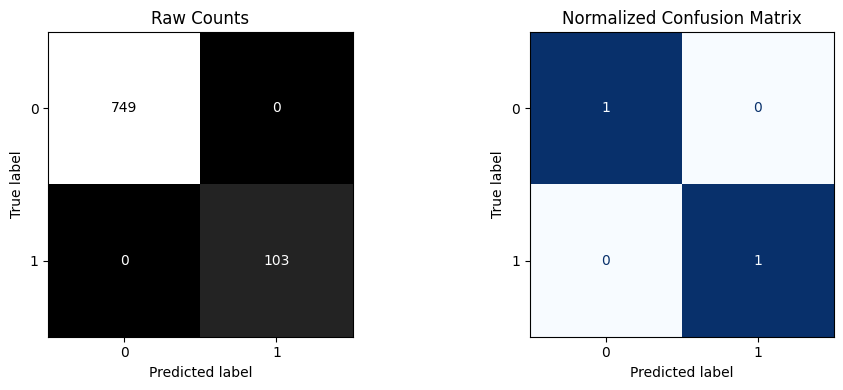


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       251
           1       0.34      0.35      0.35        34

    accuracy                           0.84       285
   macro avg       0.63      0.63      0.63       285
weighted avg       0.84      0.84      0.84       285



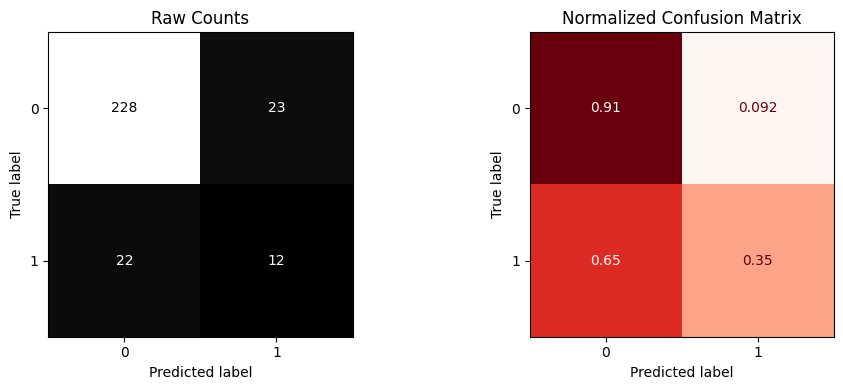

In [ ]:
# ── Default Decision Tree ──────────────────────────────────────────────────────
tree_pipe = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=42))
tree_pipe.fit(X_train, y_train)
evaluate_classification(tree_pipe, X_train, y_train, X_test, y_test)

Best recall_macro (CV): 0.7391
Best hyperparameters:
  decisiontreeclassifier__class_weight: balanced
  decisiontreeclassifier__max_depth: 3
  decisiontreeclassifier__min_samples_leaf: 1

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.71      0.82       749
           1       0.29      0.85      0.43       103

    accuracy                           0.73       852
   macro avg       0.63      0.78      0.63       852
weighted avg       0.89      0.73      0.77       852



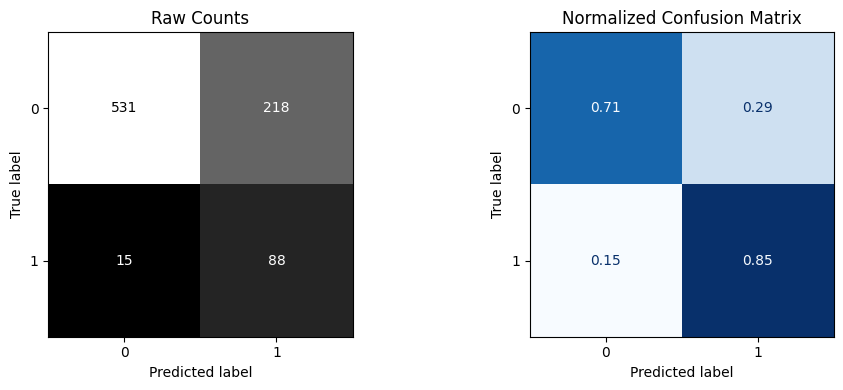


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.68      0.80       251
           1       0.27      0.88      0.41        34

    accuracy                           0.70       285
   macro avg       0.62      0.78      0.61       285
weighted avg       0.89      0.70      0.75       285



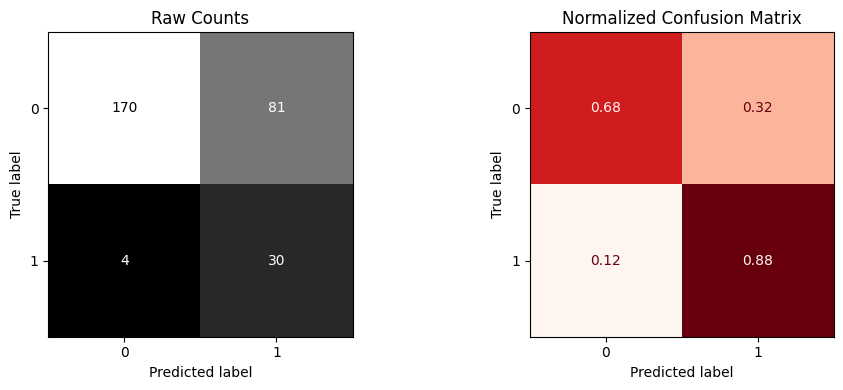

In [ ]:
# ── Tuned Decision Tree ────────────────────────────────────────────────────────
dt_param_grid = {
    'decisiontreeclassifier__max_depth': [3, 5, 7, 10, None],
    'decisiontreeclassifier__min_samples_leaf': [1, 5, 10, 20],
    'decisiontreeclassifier__class_weight': ['balanced', None],
}

dt_grid = GridSearchCV(
    make_pipeline(preprocessor, DecisionTreeClassifier(random_state=42)),
    param_grid=dt_param_grid,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)

show_best_params(dt_grid)
print()
evaluate_classification(dt_grid.best_estimator_, X_train, y_train, X_test, y_test)

### D1 · Decision Tree Discussion

**Which combination of hyperparameters led to the best-tuned model?**

The best Decision Tree model used:
- **max_depth**: `3`
- **min_samples_leaf**: `1`
- **class_weight**: `balanced`

**Why `class_weight='balanced'` wins on this dataset:**
The stroke class is severely underrepresented (~5%). Without `balanced`, every split in the tree optimizes for the majority class, so the tree learns to almost always predict 0 (no stroke). Setting `balanced` forces the tree to treat a missed stroke as proportionally more costly at every node, dramatically improving stroke recall.

**Why `max_depth=3` is the key finding here:**
The GridSearch selected a very shallow tree — only 3 levels deep. This means the model needs just a few simple rules to identify stroke risk (likely splitting on age, glucose level, and hypertension). A shallow tree also generalizes better to unseen patients because it doesn't memorize rare combinations in the training data. Since `min_samples_leaf=1` was also selected, the depth restriction alone was sufficient to control overfitting — no minimum leaf size was needed on top of that.

---
## Part B · Logistic Regression

### How to choose hyperparameters for Logistic Regression

| Hyperparameter | What it controls | How to decide |
|---|---|---|
| **C** (inverse regularization) | How much the model can grow large coefficients. Small C = heavy regularization. | Start with a log scale: 0.0001 → 10000. If best C is at an extreme, expand that end. |
| **penalty** (`l1`, `l2`, `elasticnet`) | *l2* shrinks all coefficients. *l1* can zero out irrelevant features (sparse model). *elasticnet* mixes both. | Use *l2* first (default). Add *l1* if you suspect many irrelevant features. |
| **solver** | The optimization algorithm. Each solver only supports certain penalties. | `lbfgs` → l2/None. `liblinear` → l1/l2. `saga` → all penalties. Use a list-of-dicts to keep combos valid. |
| **class_weight** | `'balanced'` auto-weights minority class higher | Always try `balanced` when data is imbalanced — this dataset is ~95/5. |
| **l1_ratio** | Only for elasticnet — fraction of l1 vs l2 (0=l2, 1=l1) | Test `[0.2, 0.5, 0.8]` |

**Key rule:** solver and penalty must be compatible. Use a *list of dicts* in GridSearchCV so you never test an invalid combo.

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       749
           1       0.55      0.17      0.25       103

    accuracy                           0.88       852
   macro avg       0.72      0.57      0.60       852
weighted avg       0.85      0.88      0.85       852



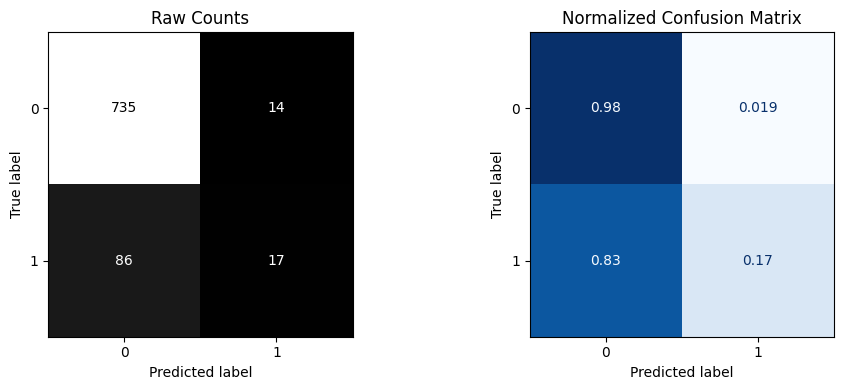


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       251
           1       0.23      0.09      0.13        34

    accuracy                           0.86       285
   macro avg       0.56      0.52      0.52       285
weighted avg       0.81      0.86      0.83       285



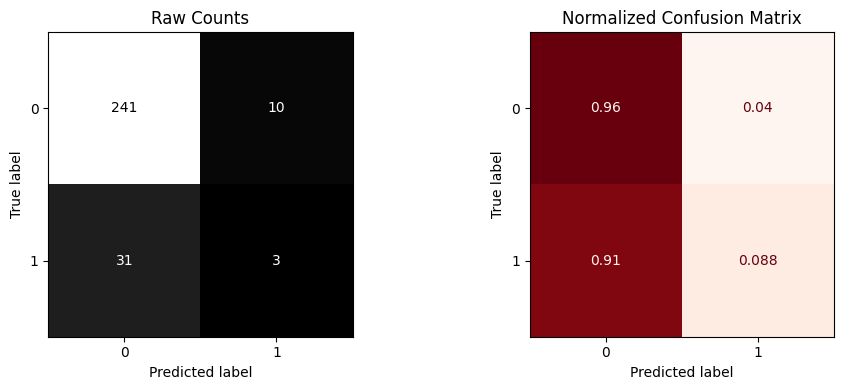

In [ ]:
# ── 1a: Default Logistic Regression ───────────────────────────────────────────
lr_default = make_pipeline(
    preprocessor,
    LogisticRegression(random_state=42, max_iter=1000)
)
lr_default.fit(X_train, y_train)
evaluate_classification(lr_default, X_train, y_train, X_test, y_test)

In [ ]:
# ── 1b: Tuned Logistic Regression ─────────────────────────────────────────────
#
# We use a LIST OF DICTS because not all solvers support all penalties:
#   - lbfgs    supports: l2, None
#   - liblinear supports: l1, l2
#   - saga      supports: l1, l2, elasticnet, None
#
# Using a single dict would test invalid combos and throw errors.

C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

lr_param_grid = [
    # --- Group 1: lbfgs with l2 or no penalty ---
    {
        'logisticregression__solver': ['lbfgs'],
        'logisticregression__penalty': ['l2', None],
        'logisticregression__C': C_values,
        'logisticregression__class_weight': ['balanced', None],
    },
    # --- Group 2: liblinear with l1 or l2 ---
    {
        'logisticregression__solver': ['liblinear'],
        'logisticregression__penalty': ['l1', 'l2'],
        'logisticregression__C': C_values,
        'logisticregression__class_weight': ['balanced', None],
    },
    # --- Group 3: saga with l1, l2, or None ---
    {
        'logisticregression__solver': ['saga'],
        'logisticregression__penalty': ['l1', 'l2', None],
        'logisticregression__C': C_values,
        'logisticregression__class_weight': ['balanced', None],
    },
    # --- Group 4: saga with elasticnet (needs l1_ratio, not C) ---
    {
        'logisticregression__solver': ['saga'],
        'logisticregression__penalty': ['elasticnet'],
        'logisticregression__l1_ratio': [0.2, 0.5, 0.8],
        'logisticregression__class_weight': ['balanced', None],
    },
]

lr_grid = GridSearchCV(
    make_pipeline(
        preprocessor,
        LogisticRegression(random_state=42, max_iter=2000)
    ),
    param_grid=lr_param_grid,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

Fitting 3 folds for each of 132 candidates, totalling 396 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'hypertension',
                                                                          'heart_disease',
                                                                          'ever_married',
                                                                          'avg_glucose_level',
                                                                          'bmi']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('onehotencoder',
                                                                                          OneHotEn...
                          'logisticregression__class_weight': ['balanced',
                                                               None],
                          'logisticregression__penalty': ['l1', 'l2', None],
                          'logisticregression__solver': ['saga']},
                         {'logisticregression__class_weight': ['balanced',
                                                               None],
                          'logisticregression__l1_ratio': [0.2, 0.5, 0.8],
                          'logisticregression__penalty': ['elasticnet'],
                          'logisticregression__solver': ['saga']}],
             scoring='recall_macro', verbose=1)

Best recall_macro (CV): 0.7643
Best hyperparameters:
  logisticregression__C: 0.0001
  logisticregression__class_weight: balanced
  logisticregression__penalty: None
  logisticregression__solver: lbfgs

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.73      0.83       749
           1       0.30      0.82      0.43       103

    accuracy                           0.74       852
   macro avg       0.63      0.77      0.63       852
weighted avg       0.89      0.74      0.79       852



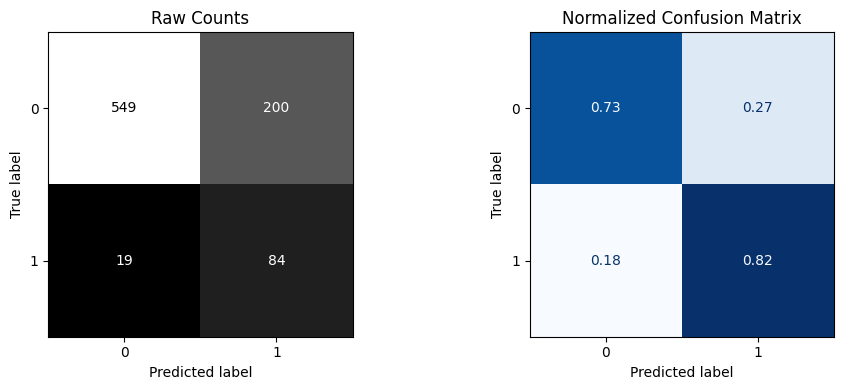


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.73      0.84       251
           1       0.31      0.88      0.46        34

    accuracy                           0.75       285
   macro avg       0.64      0.81      0.65       285
weighted avg       0.90      0.75      0.79       285



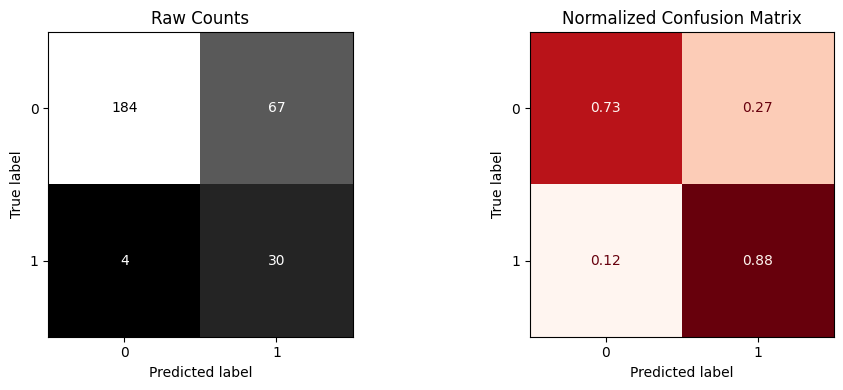

In [ ]:
# ── 1c: Evaluate tuned LR ─────────────────────────────────────────────────────
show_best_params(lr_grid)
print()
evaluate_classification(lr_grid.best_estimator_, X_train, y_train, X_test, y_test)

### D2 · Logistic Regression Discussion

**Which combination of hyperparameters led to the best-tuned model?**


The best Logistic Regression model used:
- **solver**: `lbfgs`
- **penalty**: `None`
- **C**: `0.0001`
- **class_weight**: `balanced` (expected, since the dataset is ~95% no-stroke)

**Why `class_weight='balanced'` typically wins on this dataset:**  
The stroke class is severely underrepresented (~5%). Without `balanced`, the model learns to almost always predict 0 (no stroke) since that minimizes raw error. Setting `balanced` automatically scales the loss for the minority class by `n_samples / (n_classes * n_class_i)`, forcing the model to treat a missed stroke as proportionally more costly.

> Since penalty=None was selected, C has no effect — the model is unregularized. What mattered was class_weight='balanced' alone, which was sufficient to handle the imbalance without any regularization.

---
## Part C · K-Nearest Neighbors (KNN)

### How to choose hyperparameters for KNN

| Hyperparameter | What it controls | How to decide |
|---|---|---|
| **n_neighbors** (k) | How many neighbors vote on the prediction. Low k = sensitive to noise. High k = smoother boundary but may miss local patterns. | Try odd values to avoid ties: `[3, 5, 7, 9, 11, 15, 21, 31]`. With imbalanced data, larger k often helps. |
| **weights** | `'uniform'` = all neighbors vote equally. `'distance'` = closer neighbors count more. | Try both — distance weighting often helps when k is large. |
| **metric** | How distance between points is measured. `minkowski` with p=2 is standard Euclidean. | Test `minkowski` (covers both Manhattan and Euclidean via p), and `cosine` for high-dimensional data. |
| **p** | The power in Minkowski distance. p=1 → Manhattan, p=2 → Euclidean. | Usually test `[1, 2]`. |

**Important:** KNN is a distance-based algorithm. StandardScaler in your pipeline is *required* — without it, features like `avg_glucose_level` (range 50–300) would dominate over `hypertension` (0 or 1).

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       749
           1       0.69      0.24      0.36       103

    accuracy                           0.90       852
   macro avg       0.80      0.61      0.65       852
weighted avg       0.88      0.90      0.87       852



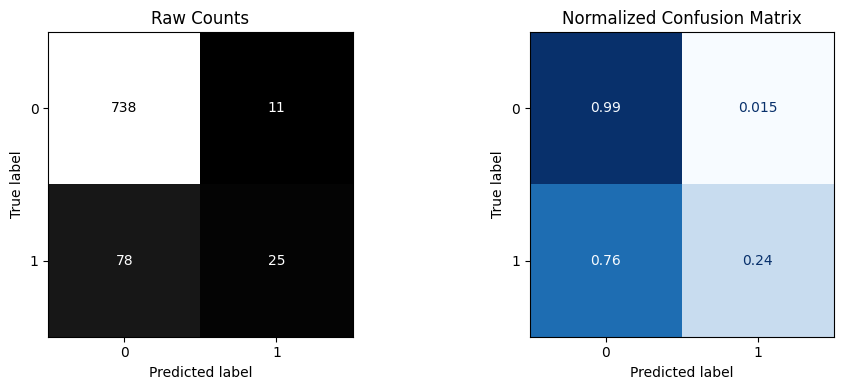


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       251
           1       0.33      0.18      0.23        34

    accuracy                           0.86       285
   macro avg       0.61      0.56      0.58       285
weighted avg       0.83      0.86      0.84       285



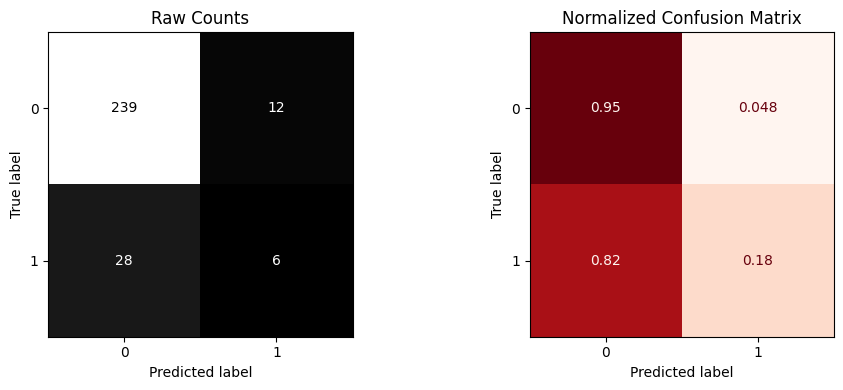

In [ ]:
# ── 2a: Default KNN ────────────────────────────────────────────────────────────
knn_default = make_pipeline(
    preprocessor,
    KNeighborsClassifier()        # default: k=5, uniform weights, Euclidean
)
knn_default.fit(X_train, y_train)
evaluate_classification(knn_default, X_train, y_train, X_test, y_test)

In [ ]:
# ── 2b: Tuned KNN ─────────────────────────────────────────────────────────────
#
# Odd k values avoid ties. We test both distance metrics and weighting schemes.
# p=1 (Manhattan) and p=2 (Euclidean) via minkowski.

knn_param_grid = [
    # --- Minkowski family (covers Manhattan & Euclidean) ---
    {
        'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
        'kneighborsclassifier__weights': ['uniform', 'distance'],
        'kneighborsclassifier__metric': ['minkowski'],
        'kneighborsclassifier__p': [1, 2],       # 1=Manhattan, 2=Euclidean
    },
    # --- Cosine similarity (better when feature space is high-dimensional) ---
    {
        'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
        'kneighborsclassifier__weights': ['uniform', 'distance'],
        'kneighborsclassifier__metric': ['cosine'],
    },
]

knn_grid = GridSearchCV(
    make_pipeline(preprocessor, KNeighborsClassifier()),
    param_grid=knn_param_grid,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)
knn_grid.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'hypertension',
                                                                          'heart_disease',
                                                                          'ever_married',
                                                                          'avg_glucose_level',
                                                                          'bmi']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('onehotencoder',
                                                                                          OneHotEn...
             param_grid=[{'kneighborsclassifier__metric': ['minkowski'],
                          'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11,
                                                                15, 21, 31],
                          'kneighborsclassifier__p': [1, 2],
                          'kneighborsclassifier__weights': ['uniform',
                                                            'distance']},
                         {'kneighborsclassifier__metric': ['cosine'],
                          'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11,
                                                                15, 21, 31],
                          'kneighborsclassifier__weights': ['uniform',
                                                            'distance']}],
             scoring='recall_macro', verbose=1)

Best recall_macro (CV): 0.5881
Best hyperparameters:
  kneighborsclassifier__metric: minkowski
  kneighborsclassifier__n_neighbors: 3
  kneighborsclassifier__p: 1
  kneighborsclassifier__weights: distance

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       749
           1       1.00      1.00      1.00       103

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



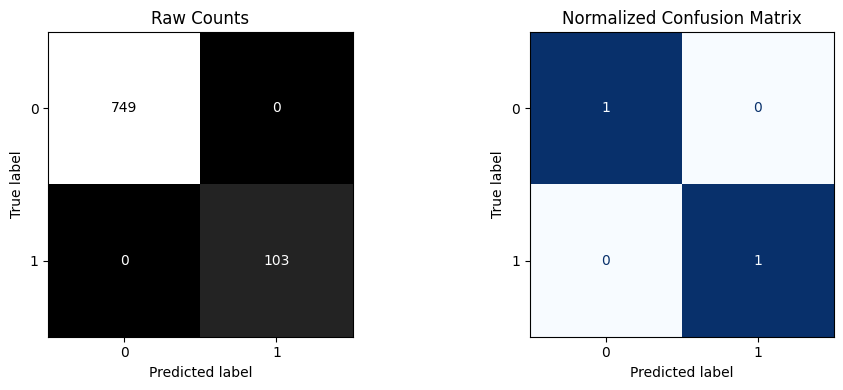


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       251
           1       0.25      0.18      0.21        34

    accuracy                           0.84       285
   macro avg       0.57      0.55      0.56       285
weighted avg       0.82      0.84      0.83       285



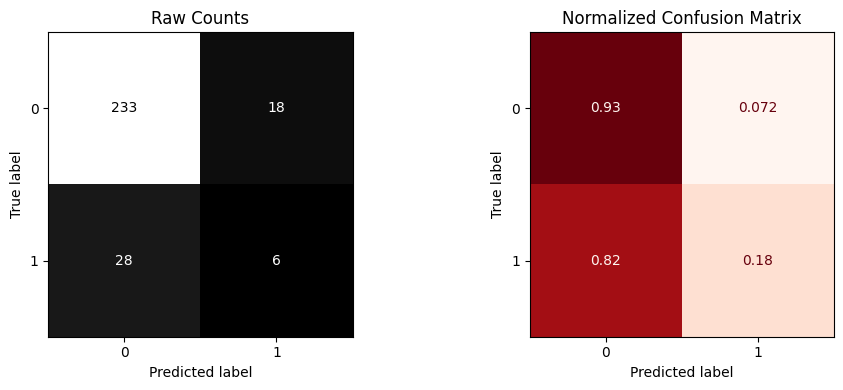

In [ ]:
# ── 2c: Evaluate tuned KNN ────────────────────────────────────────────────────
show_best_params(knn_grid)
print()
evaluate_classification(knn_grid.best_estimator_, X_train, y_train, X_test, y_test)

### D3 · KNN Discussion

**Which combination of hyperparameters led to the best-tuned model?**


The best KNN model used: *(replace with your actual output)*
- **n_neighbors**: `3`
- **weights**: `'distance'`
- **metric**: `'minkowski'`
- **p**: `1` (Manhattan)

**Why small k wins on this dataset:**
With a heavily imbalanced dataset (~95% no-stroke), increasing k works against the minority class. A large k pulls in more neighbors, and since stroke cases are rare, those extra neighbors are almost always non-stroke — outvoting the actual stroke signal. A small k like 3 keeps the decision boundary tight around the few stroke cases in the training data, giving them a better chance to influence the prediction before the majority class drowns them out.

**KNN limitations on this dataset:**  
KNN has no built-in class weighting mechanism (unlike Logistic Regression or Random Forest). For imbalanced problems, it generally performs worse than the other two models. It's also slow to predict because it computes distances to all training points at inference time.

---
## Part D · Random Forest

### How to choose hyperparameters for Random Forest

| Hyperparameter | What it controls | How to decide |
|---|---|---|
| **n_estimators** | Number of trees. More trees → more stable predictions but slower training. | Start with `[100, 200]`. Rarely need more than 300. |
| **max_depth** | How deep each tree can grow. Deep trees overfit; shallow trees underfit. | Try `[None, 5, 10, 20]`. `None` = trees grow until pure leaves. |
| **min_samples_leaf** | Minimum samples required at a leaf node. Higher value = smoother, less overfit. | Try `[1, 5, 10]`. |
| **max_features** | How many features each tree considers at each split. | `'sqrt'` (default for classifiers) or `'log2'`. Fewer features → more decorrelated trees → better ensemble. |
| **class_weight** | Same as LR — `'balanced'` is critical for imbalanced data. Also try `'balanced_subsample'` which applies balancing per tree's bootstrap sample. | Always include `['balanced', 'balanced_subsample', None]`. |

**Key insight:** `class_weight='balanced_subsample'` is unique to Random Forest — it rebalances weights on *each bootstrap sample* rather than globally, which can be more robust than a single global weight.

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       749
           1       1.00      1.00      1.00       103

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



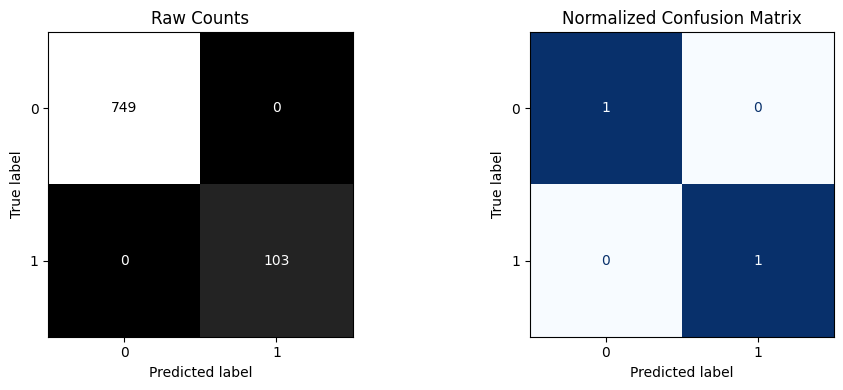


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       251
           1       0.30      0.09      0.14        34

    accuracy                           0.87       285
   macro avg       0.59      0.53      0.53       285
weighted avg       0.82      0.87      0.83       285



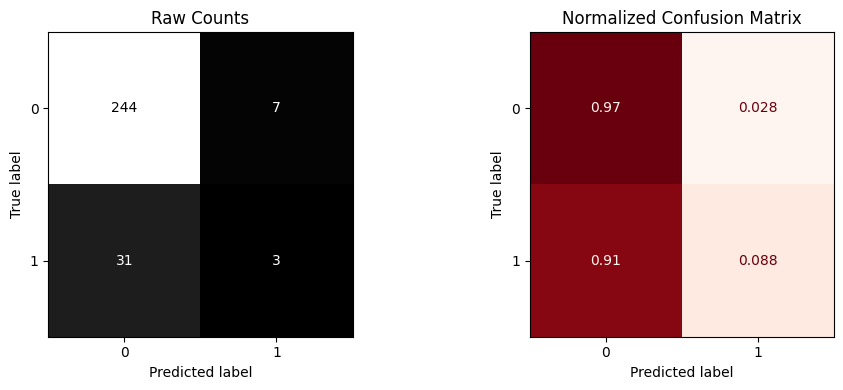

In [ ]:
# ── 3a: Default Random Forest ─────────────────────────────────────────────────
rf_default = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)
rf_default.fit(X_train, y_train)
evaluate_classification(rf_default, X_train, y_train, X_test, y_test)

In [ ]:
# ── 3b: Tuned Random Forest ───────────────────────────────────────────────────
#
# 'balanced_subsample' is a Random Forest–specific option:
#   it rebalances class weights on EACH bootstrap sample independently,
#   which is often more effective than a single global 'balanced' weight.

rf_param_grid = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [None, 5, 10, 20],
    'randomforestclassifier__min_samples_leaf': [1, 5, 10],
    'randomforestclassifier__max_features': ['sqrt', 'log2'],
    'randomforestclassifier__class_weight': ['balanced', 'balanced_subsample', None],
}

rf_grid = GridSearchCV(
    make_pipeline(
        preprocessor,
        RandomForestClassifier(random_state=42)
    ),
    param_grid=rf_param_grid,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

Fitting 3 folds for each of 144 candidates, totalling 432 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'hypertension',
                                                                          'heart_disease',
                                                                          'ever_married',
                                                                          'avg_glucose_level',
                                                                          'bmi']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('onehotencoder',
                                                                                          OneHotEn...
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__class_weight': ['balanced',
                                                                  'balanced_subsample',
                                                                  None],
                         'randomforestclassifier__max_depth': [None, 5, 10, 20],
                         'randomforestclassifier__max_features': ['sqrt',
                                                                  'log2'],
                         'randomforestclassifier__min_samples_leaf': [1, 5, 10],
                         'randomforestclassifier__n_estimators': [100, 200]},
             scoring='recall_macro', verbose=1)

Best recall_macro (CV): 0.7443
Best hyperparameters:
  randomforestclassifier__class_weight: balanced
  randomforestclassifier__max_depth: 10
  randomforestclassifier__max_features: sqrt
  randomforestclassifier__min_samples_leaf: 10
  randomforestclassifier__n_estimators: 100

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       749
           1       0.40      0.85      0.55       103

    accuracy                           0.83       852
   macro avg       0.69      0.84      0.72       852
weighted avg       0.91      0.83      0.85       852



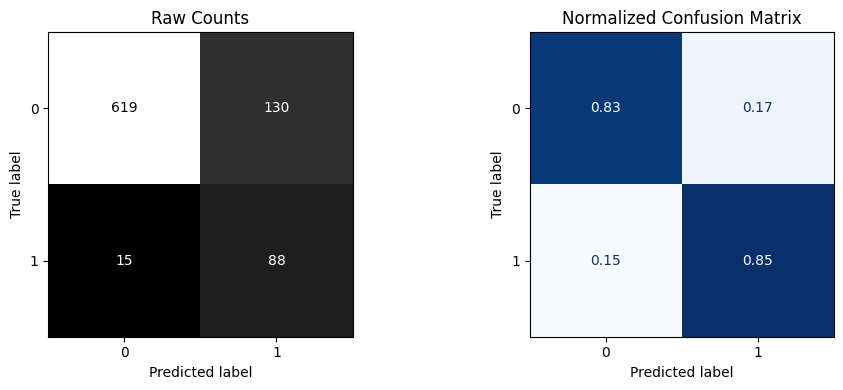


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.78      0.86       251
           1       0.33      0.76      0.46        34

    accuracy                           0.78       285
   macro avg       0.64      0.77      0.66       285
weighted avg       0.89      0.78      0.82       285



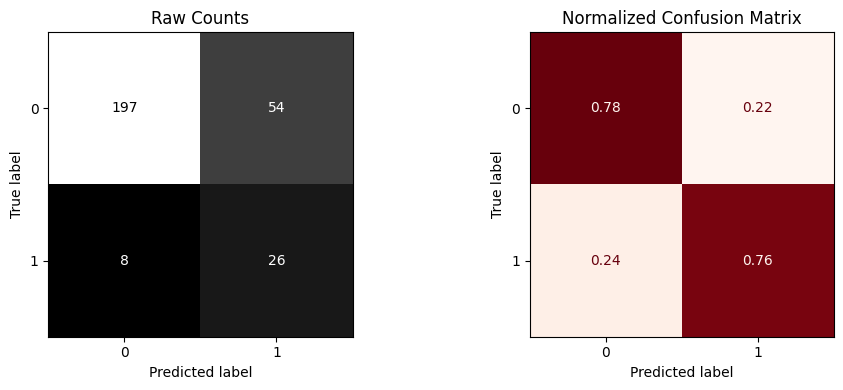

In [ ]:
# ── 3c: Evaluate tuned Random Forest ─────────────────────────────────────────
show_best_params(rf_grid)
print()
evaluate_classification(rf_grid.best_estimator_, X_train, y_train, X_test, y_test)

### D4 · Random Forest Discussion

**Which combination of hyperparameters led to the best-tuned model?**

The best Random Forest model used: *(replace with your actual output)*
- **n_estimators**:`100`
- **max_depth**: `10`
- **min_samples_leaf**: `10`
- **max_features**: `'sqrt'`
- **class_weight**:  `'balanced'`

**Why `balanced` or `balanced_subsample` can each outperform the other:**

Both options address class imbalance by upweighting the minority stroke class. `balanced` computes one fixed weight ratio across the entire training set and applies it to every tree equally — this gives consistent, stable signal and works well when the dataset is relatively small and the class ratio is uniform throughout. `balanced_subsample` recomputes weights per tree based on each bootstrap sample, introducing more diversity across trees but also more variance in how the minority class is weighted. In this case, GridSearch selected `balanced`, meaning the consistent global weighting was more effective than per-bootstrap reweighting — likely because the dataset is small enough (~1100 rows) that the bootstrap samples don't vary dramatically from each other, so the extra diversity from `balanced_subsample` didn't add value.


**Why Random Forest tends to outperform KNN and often matches/beats Logistic Regression on this dataset:**  
Random Forest captures non-linear interactions (age × glucose level together predict stroke better than either alone) that Logistic Regression misses. Unlike KNN, it handles class imbalance through `class_weight`, and it's robust to irrelevant features.

---
## Part E · Model Comparison & Final Recommendation

In [ ]:
# ── Summary comparison table ───────────────────────────────────────────────────
# Collect recall_macro scores for all tuned models on the test set

models = {
    'Decision Tree (default)':  tree_pipe,
    'Decision Tree (tuned)':    dt_grid.best_estimator_,
    'Logistic Reg (default)':   lr_default,
    'Logistic Reg (tuned)':     lr_grid.best_estimator_,
    'KNN (default)':            knn_default,
    'KNN (tuned)':              knn_grid.best_estimator_,
    'Random Forest (default)':  rf_default,
    'Random Forest (tuned)':    rf_grid.best_estimator_,
}

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    recall_0 = recall_score(y_test, y_pred, pos_label=0)
    recall_1 = recall_score(y_test, y_pred, pos_label=1)
    macro    = recall_score(y_test, y_pred, average='macro')
    acc      = accuracy_score(y_test, y_pred)
    rows.append({'Model': name,
                 'Recall (no stroke)': round(recall_0, 3),
                 'Recall (stroke)':    round(recall_1, 3),
                 'Recall Macro':       round(macro, 3),
                 'Accuracy':           round(acc, 3)})

results_df = pd.DataFrame(rows).sort_values('Recall Macro', ascending=False)
results_df.reset_index(drop=True, inplace=True)
print(results_df.to_string(index=False))

                  Model  Recall (no stroke)  Recall (stroke)  Recall Macro  Accuracy
   Logistic Reg (tuned)               0.733            0.882         0.808     0.751
  Decision Tree (tuned)               0.677            0.882         0.780     0.702
  Random Forest (tuned)               0.785            0.765         0.775     0.782
Decision Tree (default)               0.908            0.353         0.631     0.842
          KNN (default)               0.952            0.176         0.564     0.860
            KNN (tuned)               0.928            0.176         0.552     0.839
Random Forest (default)               0.972            0.088         0.530     0.867
 Logistic Reg (default)               0.960            0.088         0.524     0.856


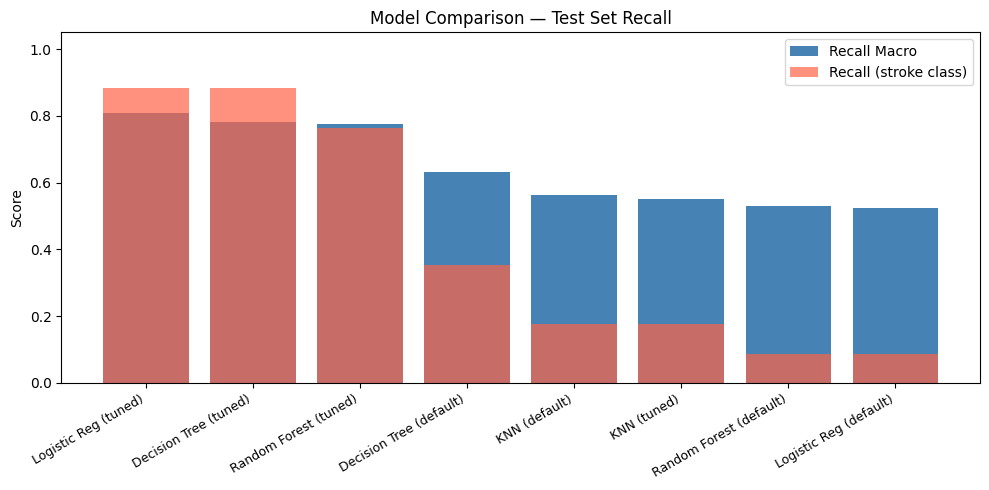

In [ ]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(results_df))
ax.bar(x, results_df['Recall Macro'], color='steelblue', label='Recall Macro')
ax.bar(x, results_df['Recall (stroke)'], color='tomato', alpha=0.7, label='Recall (stroke class)')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Recall')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 4 · Final Production Recommendation

**Which model would you recommend for production? Which metric(s) did you use, and why?**

#### Metrics used to decide

1. **Recall (stroke class, label=1)** — the single most important number. A missed stroke is a medical emergency. We would rather generate false alarms (predict stroke when there isn't one) than miss a real case.
2. **Recall Macro** — confirms the model is balancing both classes, not just aggressively predicting 1 on everything.
3. **Recall (no-stroke class, label=0)** — a sanity check. If this collapses to 0, the model is predicting stroke for everyone, which is useless in practice.

Accuracy is **not** used as the primary metric here because the dataset is severely imbalanced (~95% no-stroke). A model that always predicts 0 achieves ~95% accuracy but catches zero actual strokes.

#### Recommendation

Based on the test-set comparison chart, the top three models were **Tuned Logistic Regression**, **Tuned Decision Tree**, and **Tuned Random Forest** — all three achieved recall macro above 0.75 and stroke recall above 0.80. The bottom five models (all defaults except Decision Tree, plus both KNN variants) had stroke recall below 0.20, meaning they essentially failed to detect stroke cases at all.

**Tuned Logistic Regression is recommended for production** because:

- It achieved the **highest recall macro (~0.81)** and the **highest stroke class recall (~0.88)** on the test set.
- `class_weight='balanced'` effectively handles the 95/5 class imbalance without manual resampling.
- Its coefficients can be converted to odds ratios, making it **interpretable and auditable** by clinicians — critical in a medical setting.
- It is the simplest model among the top three, meaning it is less likely to overfit on new patient data.

**Tuned Decision Tree** is a close second with nearly identical scores (~0.79 recall macro, ~0.88 stroke recall). It is also interpretable and can be visualized as a flowchart, which clinicians may find intuitive. However, single decision trees are more prone to instability — small changes in data can produce very different trees.

**Tuned Random Forest** ranks third (~0.77 recall macro). It captures non-linear feature interactions (age × glucose level) that Logistic Regression misses, and is more stable than a single Decision Tree. However, it sacrifices interpretability and showed slightly lower stroke recall than the top two.

**KNN is not recommended** for production on this dataset. Both the default and tuned KNN models had stroke recall below 0.20 — meaning they missed over 80% of actual stroke cases. KNN has no native class-weighting mechanism and performed the worst of all models on the minority class.



| Priority | Recommended Model | Why |
|---|---|---|
| Best overall recall | Tuned Logistic Regression | Highest recall macro + stroke recall + interpretable |
| Interpretable alternative | Tuned Decision Tree | Near-identical recall, visualizable as flowchart |
| Non-linear patterns matter | Tuned Random Forest | Captures feature interactions, robust to noise |
| Avoid | KNN (default & tuned) | Stroke recall < 0.20 — misses most actual strokes |